# 03 — Calibration-weight sweep
Mirror the source paper's central sensitivity experiment: vary the calibration weight and measure calibration against predictive quality. Select weights on validation data only in confirmatory work.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import TrainingConfig
from innovcal.data import simulate_multivariate_series
from innovcal.experiments.comparison import lambda_sweep
OUT = ROOT / 'results' / 'lambda_sweep'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
values = simulate_multivariate_series(1200, regime='nonlinear', seed=301)
weights = [0.0, 1.0, 10.0, 50.0, 100.0, 250.0, 500.0]
sweep = lambda_sweep(values, weights, training_config=TrainingConfig(epochs=150, patience=20, seed=301))
display(sweep)
sweep.to_csv(OUT / 'lambda_sweep.csv', index=False)

/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/evaluation/metrics.py:29: RuntimeWarning: divide by zero encountered in matmul
  projected_target = target @ projections.T
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/evaluation/metrics.py:29: RuntimeWarning: overflow encountered in matmul
  projected_target = target @ projections.T
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/evaluation/metrics.py:29: RuntimeWarning: invalid value encountered in matmul
  projected_target = target @ projections.T


,lambda_cal,best_epoch,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
0,0.0,38,5.320390,0.957473,1.256993,0.897727,3.103160,4.021031,0.000938,0.057344,0.064914,0.001121,0.047086,0.065440
1,1.0,38,5.320582,0.957537,1.257048,0.897727,3.105032,4.021317,0.000930,0.057643,0.064949,0.001114,0.047228,0.065519
2,10.0,40,5.325393,0.958516,1.258137,0.898864,3.116341,4.025871,0.000898,0.060620,0.063147,0.001081,0.049560,0.064990
3,50.0,48,5.346117,0.962718,1.263224,0.900000,3.143340,4.043038,0.000794,0.070625,0.062219,0.000971,0.057060,0.065712
4,100.0,55,5.362663,0.966540,1.267924,0.902273,3.159098,4.064138,0.000636,0.075158,0.060644,0.000798,0.060766,0.063641
5,250.0,44,5.376506,0.971733,1.274506,0.906818,3.215081,4.081454,0.000551,0.074971,0.058221,0.000660,0.063046,0.064634
6,500.0,44,5.405795,0.974253,1.278983,0.915909,3.258888,4.085023,0.000612,0.069956,0.056480,0.000604,0.064486,0.059284


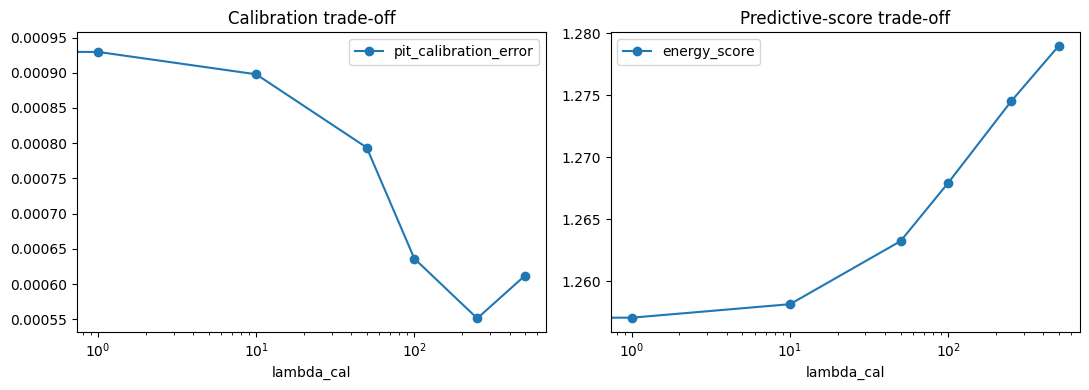

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sweep.plot(x='lambda_cal', y='pit_calibration_error', marker='o', logx=True, ax=axes[0])
sweep.plot(x='lambda_cal', y='energy_score', marker='o', logx=True, ax=axes[1])
axes[0].set_title('Calibration trade-off'); axes[1].set_title('Predictive-score trade-off')
plt.tight_layout()